In [ ]:
# ============================================
# 추가 데이터 전처리
# ============================================
# AI Hub에서 직접 다운받은 경구약제 단일 이미지 데이터(TL_81_단일)를
# YOLO 학습 포맷으로 변환한 전처리 코드입니다.
#
# 1. 전달받은 dataset.zip을 Colab에 업로드
# 2. 아래 코드로 압축 해제 후 실행
# !unzip dataset.zip -d /content/dataset
#
# Cell 3 (convert 함수)는 전처리 과정 기록용입니다.
# dataset.zip을 사용하면 실행할 필요 없어요.
# ============================================

In [1]:
!pip install opencv-python

In [28]:
import os
import json
import cv2

image_train_dir = "/content/dataset/images/train"
image_val_dir = "/content/dataset/images/val"
json_root_dir = "/content/TL_81_단일"

label_train_dir = "/content/dataset/labels/train"
label_val_dir = "/content/dataset/labels/val"

os.makedirs(label_train_dir, exist_ok=True)
os.makedirs(label_val_dir, exist_ok=True)

def convert(image_dir, label_dir):
    for img_name in os.listdir(image_dir):

        base_id = img_name.split('_')[0]

        json_folder = base_id + "_json"
        json_folder_path = os.path.join(json_root_dir, json_folder)

        if not os.path.exists(json_folder_path):
            continue

        json_name = img_name.replace(".png", ".json")
        json_path = os.path.join(json_folder_path, json_name)
        if not os.path.exists(json_path):
            print(f"[WARN] JSON 없음: {json_name}")
            continue

        img_path = os.path.join(image_dir, img_name)
        img = cv2.imread(img_path)
        if img is None:
            print(f"[WARN] 이미지 로딩 실패: {img_path}")
            continue
        h, w, _ = img.shape

        with open(json_path, encoding="utf-8") as f:
            data = json.load(f)

        label_path = os.path.join(label_dir, img_name.replace(".png", ".txt"))

        with open(label_path, "w") as f:
            for obj in data["annotations"]:
                x, y, bw, bh = obj["bbox"]

                x_center = (x + bw/2) / w
                y_center = (y + bh/2) / h
                bw /= w
                bh /= h

                f.write(f"0 {x_center} {y_center} {bw} {bh}\n")

convert(image_train_dir, label_train_dir)
convert(image_val_dir, label_val_dir)
# 전처리 과정 기록용 - 실행 불필요 (dataset.zip 사용)

In [15]:
with open('/content/dataset/data.yaml', 'w') as f:
    f.write("""train: /content/dataset/images/train
val: /content/dataset/images/val

nc: 1
names: ['pill']
""")

In [21]:
print(os.listdir('/content/dataset/images/train')[:5])

['K-038884_0_0_1_0_90_080_200.png', 'K-038884_0_0_1_1_75_020_200.png', 'K-038884_0_0_1_0_90_060_200.png', 'K-038884_0_0_0_1_75_280_200.png', 'K-038884_0_0_0_1_75_240_200.png']


In [22]:
print(os.listdir('/content/dataset/labels/train')[:5])

['K-038884_0_0_1_0_75_000_200.txt', 'K-038884_0_0_0_1_75_320_200.txt', 'K-038884_0_0_1_0_75_260_200.txt', 'K-038884_0_0_1_0_75_140_200.txt', 'K-038884_0_0_0_1_75_260_200.txt']


In [23]:
for root, dirs, files in os.walk('/content/dataset'):
    print(root, "→", len(files), "files")

/content/dataset → 1 files
/content/dataset/images → 0 files
/content/dataset/images/val → 40 files
/content/dataset/images/train → 160 files
/content/dataset/labels → 2 files
/content/dataset/labels/val → 40 files
/content/dataset/labels/train → 160 files


In [27]:
print(len(os.listdir('/content/dataset/images/train')))
print(len(os.listdir('/content/dataset/labels/train')))
print(len(os.listdir('/content/dataset/images/val')))
print(len(os.listdir('/content/dataset/labels/val')))

160
160
40
40


In [29]:
img_stems = set(f.replace('.png','') for f in os.listdir('/content/dataset/images/train'))
lbl_stems = set(f.replace('.txt','') for f in os.listdir('/content/dataset/labels/train'))
missing = img_stems - lbl_stems
print(f"라벨 없는 이미지: {len(missing)}개")
if missing:
    print(missing)

라벨 없는 이미지: 0개


In [30]:
error_files = []
for fname in os.listdir('/content/dataset/labels/train'):
    with open(f'/content/dataset/labels/train/{fname}') as f:
        for line in f:
            vals = list(map(float, line.strip().split()))
            if any(v < 0 or v > 1 for v in vals[1:]):
                error_files.append(fname)
print(f"범위 오류 라벨: {len(error_files)}개")

범위 오류 라벨: 0개


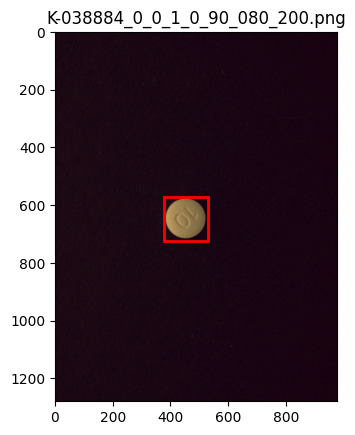

In [31]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

img_name = os.listdir('/content/dataset/images/train')[0]
img_path = f'/content/dataset/images/train/{img_name}'
lbl_path = f'/content/dataset/labels/train/{img_name.replace(".png", ".txt")}'

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]

fig, ax = plt.subplots(1)
ax.imshow(img)
with open(lbl_path) as f:
    for line in f:
        _, cx, cy, bw, bh = map(float, line.strip().split())
        x1 = (cx - bw/2) * w
        y1 = (cy - bh/2) * h
        rect = patches.Rectangle((x1, y1), bw*w, bh*h,
                                   linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
plt.title(img_name)
plt.show()